In [13]:
import pandas as pd
import numpy as np
import logging
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import shap
import warnings
warnings.filterwarnings('ignore')

ROOT     = Path('..').resolve()
DATA_DIR = ROOT / 'data'
TODAY    = pd.Timestamp.today().normalize()

plt.rcParams.update({
    'figure.dpi':        120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         11,
})
COLORS = {
    'active':  '#22c55e',
    'churned': '#ef4444',
    'blue':    '#3b82f6',
    'orange':  '#f97316',
}

print(f"ROOT     : {ROOT}")
print(f"DATA_DIR : {DATA_DIR}")
print(f"TODAY    : {TODAY.date()}")

ROOT     : C:\Users\ADMIN\Documents\saas-revenue-analytics-stack
DATA_DIR : C:\Users\ADMIN\Documents\saas-revenue-analytics-stack\data
TODAY    : 2026-04-28


In [14]:
subs = pd.read_csv(
    DATA_DIR / 'subscriptions.csv',
    parse_dates=['signup_date', 'churn_date']
)

events = pd.read_csv(
    DATA_DIR / 'product_events.csv',
    parse_dates=['event_date']
)

print(f"Subs: {len(subs):,} rows | Events: {len(events):,} rows")

churn_rate = subs['status'].eq('churned').mean()
print(f"Churn rate: {churn_rate:.1%}")

print(f"Events range: {events['event_date'].min().date()} → {events['event_date'].max().date()}")

Subs: 500 rows | Events: 212,110 rows
Churn rate: 27.2%
Events range: 2025-04-20 → 2026-04-21


In [15]:
subs['ref_date']     = subs['churn_date'].fillna(TODAY)
subs['tenure_days']  = (subs['ref_date'] - subs['signup_date']).dt.days.clip(lower=1)
subs['tenure_weeks'] = subs['tenure_days'] / 7
subs['plan_encoded'] = subs['plan'].map({'starter': 0, 'growth': 1, 'pro': 2, 'enterprise': 3})

# Filter events — no leakage
events_clean = events.merge(
    subs[['user_id', 'signup_date', 'ref_date']], on='user_id', how='left'
)
events_clean = events_clean[
    (events_clean['event_date'] >= events_clean['signup_date']) &
    (events_clean['event_date'] <= events_clean['ref_date'])
]
print(f"Events after leakage filter: {len(events_clean):,}")

# Core engagement
agg = events_clean.groupby('user_id').agg(
    total_events    = ('event_id',   'count'),
    active_days     = ('event_date', 'nunique'),
    total_sessions  = ('session_id', 'nunique'),
    unique_events   = ('event_name', 'nunique'),
    last_event_date = ('event_date', 'max'),
).reset_index()

# FIXED — relative to ref_date, not TODAY
ref_dates = subs.set_index('user_id')['ref_date']
agg['days_since_last_event'] = (
    agg['user_id'].map(ref_dates) - agg['last_event_date']
).dt.days
agg['events_per_day'] = (agg['total_events'] / agg['active_days'].clip(lower=1)).round(2)

# Login count
login_counts = (
    events_clean[events_clean['event_name'].isin(['login', 'sso_login'])]
    .groupby('user_id').size().reset_index(name='login_count')
)

# Advanced feature usage
ADVANCED = [
    'integration_connected', 'automation_created', 'api_key_generated',
    'webhook_created', 'bulk_export', 'scheduled_report_set',
    'custom_dashboard_built', 'api_called'
]
advanced_counts = (
    events_clean[events_clean['event_name'].isin(ADVANCED)]
    .groupby('user_id').size().reset_index(name='advanced_feature_uses')
)

# FIXED — last 30 days relative to each user's ref_date
# events_clean already has ref_date — no second merge needed
recent = (
    events_clean[
        events_clean['event_date'] >= (events_clean['ref_date'] - pd.Timedelta(days=30))
    ]
    .groupby('user_id').size().reset_index(name='events_last_30d')
)

# Merge everything
features = (
    subs[['user_id','plan','plan_encoded','mrr','payment_failures','tenure_days','status']]
    .merge(agg[['user_id','total_events','active_days','total_sessions',
                'unique_events','days_since_last_event','events_per_day']], on='user_id', how='left')
    .merge(login_counts,    on='user_id', how='left')
    .merge(advanced_counts, on='user_id', how='left')
    .merge(recent,          on='user_id', how='left')
)

FILL_ZERO = ['total_events','active_days','total_sessions','unique_events',
             'login_count','advanced_feature_uses','events_last_30d']
features[FILL_ZERO]               = features[FILL_ZERO].fillna(0)
features['days_since_last_event'] = features['days_since_last_event'].fillna(999)
features['events_per_day']        = features['events_per_day'].fillna(0)
features['churned']               = (features['status'] == 'churned').astype(int)

FEATURE_COLS = [
    'plan_encoded', 'mrr', 'payment_failures', 'tenure_days',
    'total_events', 'active_days', 'total_sessions', 'unique_events',
    'days_since_last_event', 'events_per_day', 'login_count',
    'advanced_feature_uses', 'events_last_30d'
]

print(f"Feature matrix : {features[FEATURE_COLS].shape}")
print(f"Churn rate     : {features['churned'].mean():.1%}")
print(f"Nulls          : {features[FEATURE_COLS].isna().sum().sum()}")

Events after leakage filter: 212,110
Feature matrix : (500, 13)
Churn rate     : 27.2%
Nulls          : 0


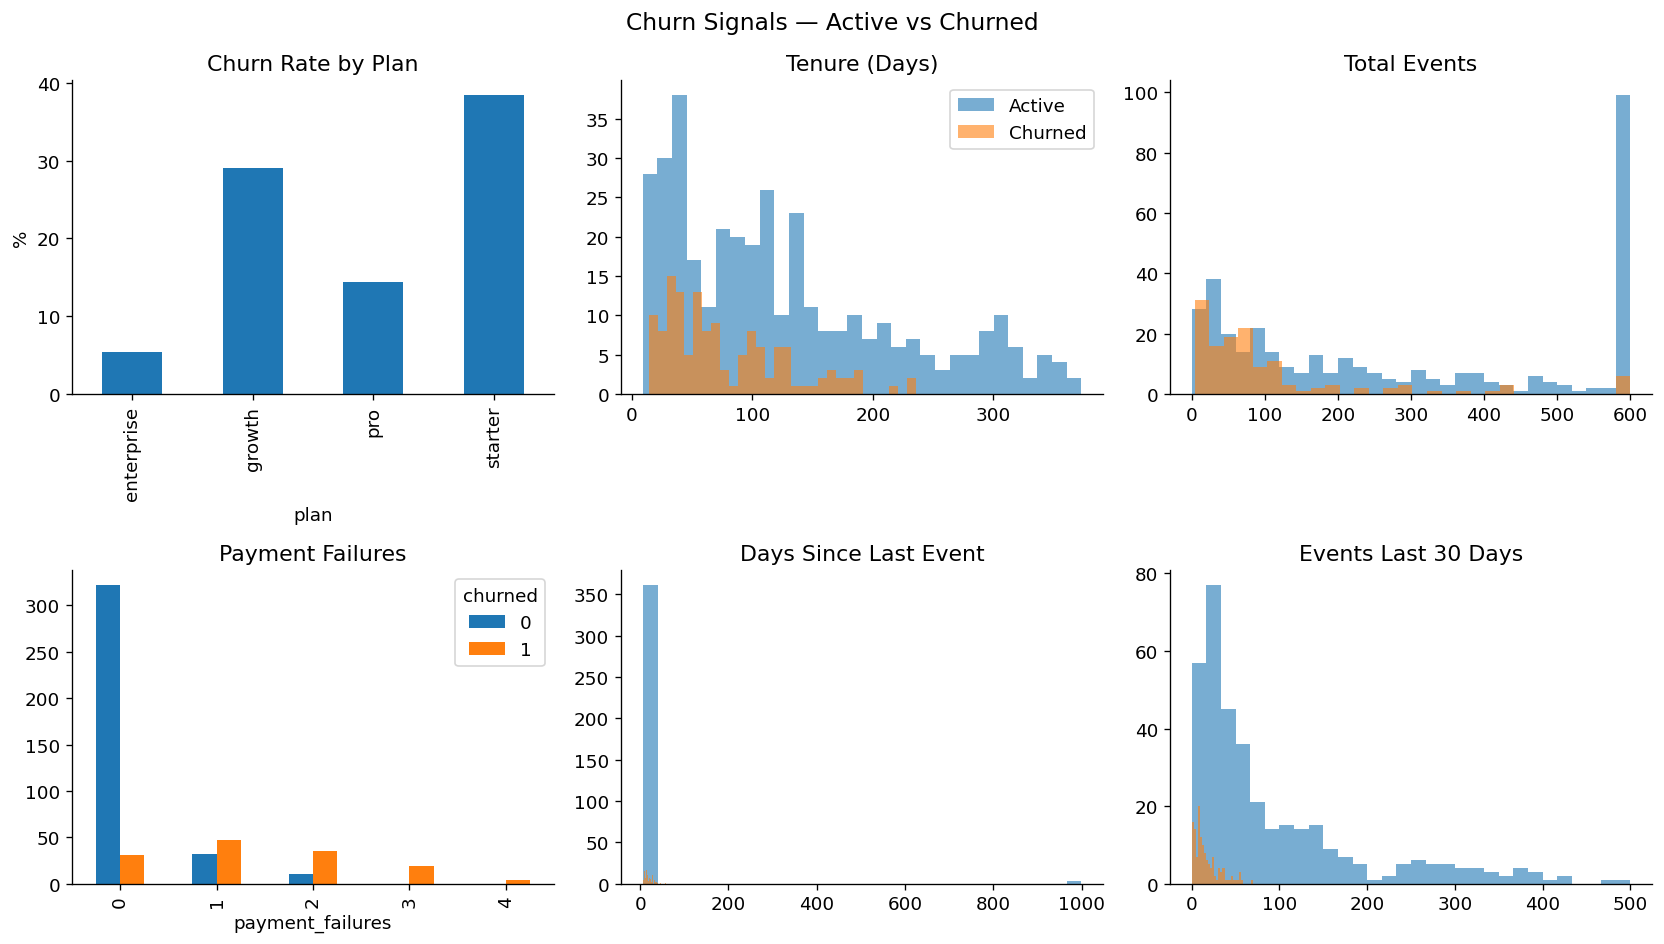

In [16]:
churned_df = features[features['churned'] == 1]
active_df  = features[features['churned'] == 0]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Churn Signals — Active vs Churned', fontsize=14)

# 1. Churn rate by plan
ax = axes[0, 0]
(features.groupby('plan')['churned'].mean() * 100).plot(kind='bar', ax=ax)
ax.set_title('Churn Rate by Plan')
ax.set_ylabel('%')

# 2. Tenure
ax = axes[0, 1]
ax.hist(active_df['tenure_days'], bins=30, alpha=0.6, label='Active')
ax.hist(churned_df['tenure_days'], bins=30, alpha=0.6, label='Churned')
ax.set_title('Tenure (Days)')
ax.legend()

# 3. Total events
ax = axes[0, 2]
ax.hist(active_df['total_events'].clip(upper=600), bins=30, alpha=0.6)
ax.hist(churned_df['total_events'].clip(upper=600), bins=30, alpha=0.6)
ax.set_title('Total Events')

# 4. Payment failures
ax = axes[1, 0]
(features.groupby(['payment_failures','churned']).size()
 .unstack(fill_value=0)
 .plot(kind='bar', ax=ax))
ax.set_title('Payment Failures')

# 5. Days since last event
ax = axes[1, 1]
ax.hist(active_df['days_since_last_event'], bins=30, alpha=0.6)
ax.hist(churned_df['days_since_last_event'], bins=30, alpha=0.6)
ax.set_title('Days Since Last Event')

# 6. Events last 30 days
ax = axes[1, 2]
ax.hist(active_df['events_last_30d'], bins=30, alpha=0.6)
ax.hist(churned_df['events_last_30d'], bins=30, alpha=0.6)
ax.set_title('Events Last 30 Days')

plt.tight_layout()
plt.show()

In [17]:
print(features.groupby('status')['days_since_last_event'].mean().round(1))

status
active     16.7
churned    18.4
Name: days_since_last_event, dtype: float64


In [18]:
X = features[FEATURE_COLS]
y = features['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Churn rate → Train: {y_train.mean():.2%}, Test: {y_test.mean():.2%}")

Train: (400, 13), Test: (100, 13)
Churn rate → Train: 27.25%, Test: 27.00%


In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)
lr.fit(X_train_scaled, y_train)

lr_preds = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]

# Metrics
lr_auc = roc_auc_score(y_test, lr_proba)

print("\nLogistic Regression")
print(f"AUC: {lr_auc:.3f}")
print(classification_report(y_test, lr_preds, target_names=['Active','Churned']))


Logistic Regression
AUC: 0.985
              precision    recall  f1-score   support

      Active       0.97      0.96      0.97        73
     Churned       0.89      0.93      0.91        27

    accuracy                           0.95       100
   macro avg       0.93      0.94      0.94       100
weighted avg       0.95      0.95      0.95       100



In [20]:

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    verbosity=0,
)

xgb.fit(X_train, y_train)

xgb_proba = xgb.predict_proba(X_test)[:, 1]
xgb_preds = (xgb_proba >= 0.5).astype(int)

print("\nXGBoost")
print(f"AUC: {roc_auc_score(y_test, xgb_proba):.3f}")
print(classification_report(y_test, xgb_preds, target_names=['Active','Churned']))


XGBoost
AUC: 0.989
              precision    recall  f1-score   support

      Active       1.00      0.96      0.98        73
     Churned       0.90      1.00      0.95        27

    accuracy                           0.97       100
   macro avg       0.95      0.98      0.96       100
weighted avg       0.97      0.97      0.97       100



In [21]:
xgb_auc = roc_auc_score(y_test, xgb_proba)
lr_auc  = roc_auc_score(y_test, lr_proba)

In [22]:
cv_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    verbosity=0,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(cv_model, X, y, cv=cv, scoring='roc_auc')

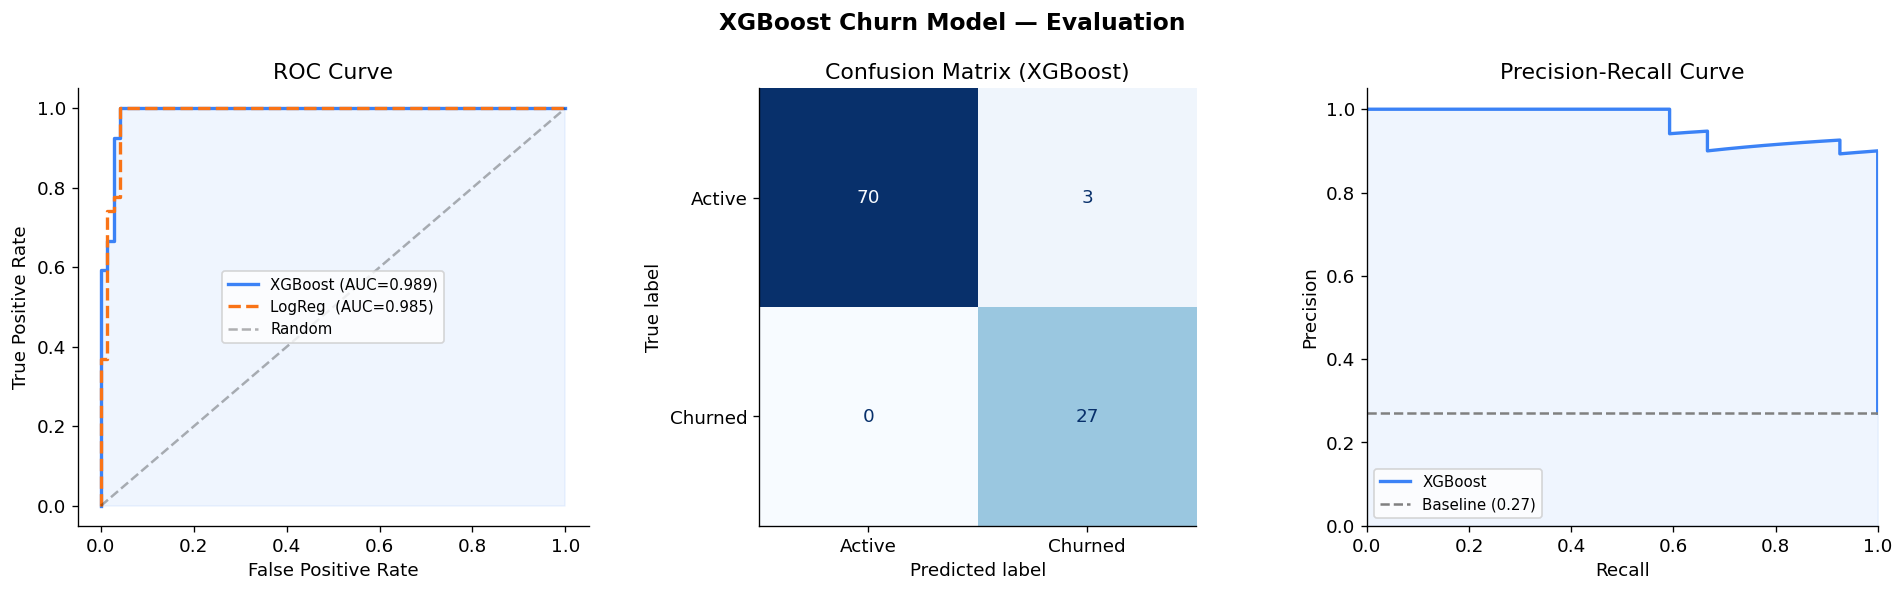

Model Comparison
LogReg AUC     : 0.9848
XGBoost AUC    : 0.9888
XGB CV AUC     : 0.9842 ± 0.0093


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('XGBoost Churn Model — Evaluation', fontsize=14, fontweight='bold')

# ROC Curve
ax = axes[0]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_proba)
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, lr_proba)
ax.plot(fpr_xgb, tpr_xgb, color=COLORS['blue'],   lw=2, label=f'XGBoost (AUC={xgb_auc:.3f})')
ax.plot(fpr_lr,  tpr_lr,  color=COLORS['orange'],  lw=2, linestyle='--', label=f'LogReg  (AUC={lr_auc:.3f})')
ax.plot([0,1], [0,1], 'k--', alpha=0.3, label='Random')
ax.fill_between(fpr_xgb, tpr_xgb, alpha=0.08, color=COLORS['blue'])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend(fontsize=9)

# Confusion Matrix
ax = axes[1]
cm   = confusion_matrix(y_test, xgb_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Active','Churned'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix (XGBoost)')

# Precision-Recall
ax = axes[2]
prec, rec, _ = precision_recall_curve(y_test, xgb_proba)
ax.plot(rec, prec, color=COLORS['blue'], lw=2, label='XGBoost')
ax.axhline(y_test.mean(), color='gray', linestyle='--', label=f'Baseline ({y_test.mean():.2f})')
ax.fill_between(rec, prec, alpha=0.08, color=COLORS['blue'])
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

print("Model Comparison")
print(f"LogReg AUC     : {lr_auc:.4f}")
print(f"XGBoost AUC    : {xgb_auc:.4f}")

if 'cv_scores' in globals():
    print(f"XGB CV AUC     : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
else:
    print("XGB CV AUC     : (not computed)")

In [24]:
features.groupby('churned')['events_last_30d'].describe()

,count,mean,std,min,25%,50%,75%,max
churned,,,,,,,,
0,364.0,92.714286,102.135602,0.0,23.0,50.5,128.00,500.0
1,136.0,16.095588,14.710479,0.0,5.0,11.0,23.25,70.0


SHAP Feature Importance
              feature  mean_shap
days_since_last_event   2.610008
     payment_failures   1.605941
      events_last_30d   1.315547
          tenure_days   0.751787
       events_per_day   0.696563
          login_count   0.300023
         total_events   0.267041
       total_sessions   0.260629
        unique_events   0.253175
          active_days   0.223078
         plan_encoded   0.110620
advanced_feature_uses   0.062103
                  mrr   0.020326


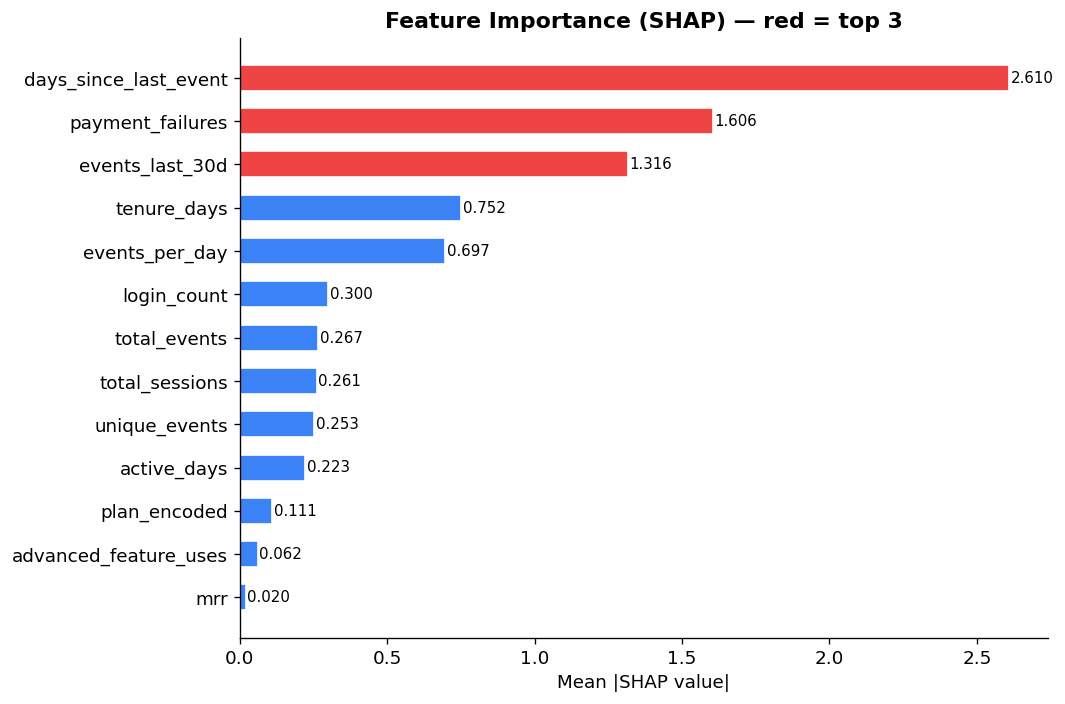

In [25]:
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

shap_importance = pd.DataFrame({
    'feature':   FEATURE_COLS,
    'mean_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_shap', ascending=False).reset_index(drop=True)

print("SHAP Feature Importance")
print(shap_importance.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
bar_colors = [COLORS['churned'] if i < 3 else COLORS['blue']
              for i in range(len(shap_importance))]
ax.barh(shap_importance['feature'], shap_importance['mean_shap'],
        color=bar_colors, edgecolor='white', height=0.6)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Feature Importance (SHAP) — red = top 3', fontweight='bold')
ax.invert_yaxis()
for i, (_, row) in enumerate(shap_importance.iterrows()):
    ax.text(row['mean_shap'] + 0.005, i, f"{row['mean_shap']:.3f}",
            va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [26]:
# Score users
features['churn_probability'] = xgb.predict_proba(features[FEATURE_COLS])[:, 1]
features['risk_tier'] = pd.cut(
    features['churn_probability'],
    bins=[0, 0.30, 0.60, 1.0],
    labels=['low', 'medium', 'high']
)

active_scored = features[features['status'] == 'active']

# --- Summary ---
total_mrr     = active_scored['mrr'].sum()
high_risk_mrr = active_scored.loc[active_scored['risk_tier'] == 'high', 'mrr'].sum()

print(f"High-risk MRR: ${high_risk_mrr:,.0f} ({high_risk_mrr/total_mrr*100:.1f}% of active)")

# --- Top risk users ---
top_risk = (
    active_scored[['user_id','plan','mrr','churn_probability']]
    .sort_values('churn_probability', ascending=False)
    .head(10)
)
print("\nTop 10 high-risk users:")
print(top_risk.to_string(index=False, float_format='%.3f'))

# --- Save output ---
output = features[[
    'user_id','plan','mrr','status',
    'tenure_days','total_events','active_days',
    'payment_failures','days_since_last_event',
    'events_last_30d','churn_probability','risk_tier'
]].copy()

output.to_csv(DATA_DIR / 'churn_scores.csv', index=False)
print("\nSaved → data/churn_scores.csv")

High-risk MRR: $147 (0.1% of active)

Top 10 high-risk users:
 user_id    plan  mrr  churn_probability
usr_0035 starter   49              0.983
usr_0384 starter   49              0.978
usr_0128 starter   49              0.727
usr_0411 starter   49              0.591
usr_0266 starter   49              0.396
usr_0314 starter   49              0.380
usr_0081 starter   49              0.338
usr_0188 starter   49              0.284
usr_0093 starter   49              0.268
usr_0034 starter   49              0.262

Saved → data/churn_scores.csv
